# makemore part 3 — Activations, Gradients & BatchNorm

## What this notebook is about

We keep the **same model as part 2** (a character-level MLP: embed `block_size=3` characters → concat → hidden `tanh` layers → output logits over 27 chars). The model doesn't change. What changes is **how we make it train well**.

The whole point of part 3 is one idea:

> A deep net only trains well if the **activations** (forward pass) and the **gradients** (backward pass) stay at a healthy scale through every layer. If they saturate, vanish, or explode, training is slow or dead — no matter how good the architecture is.

So instead of just running training and hoping, we learn to **look inside the network** and fix the scale of signals layer by layer.

## The story, step by step

1. **Fix the initial loss.**
   At step 0 the loss should be just `-log(1/27) ≈ 3.29` (uniform guess). Instead it starts much higher because the initial logits are wildly confident. Fix: make the output layer output ~0 logits → set `b2 = 0` and shrink `W2` (×0.01).

2. **Fix the saturated tanh.**
   The hidden pre-activations are too spread out, so many `tanh` outputs sit at ±1 (the flat region). There the local gradient `(1 - t²) ≈ 0`, so those neurons are **dead** and learn nothing. Fix: shrink `W1` so `hpreact` stays in a small range around 0.

3. **Kaiming init.**
   Shrinking weights by hand is hacky. The principled rule: scale each layer's weights by `gain / sqrt(fan_in)` (for tanh, `gain = 5/3`) so the activation std stays ~1 as it passes through each layer. This is what keeps the forward pass well-scaled by construction.

4. **Batch normalization.**
   Instead of relying on perfect init, just **normalize the pre-activations to unit gaussian per batch**, then let learnable `gamma`/`beta` rescale. This keeps every layer healthy regardless of weight drift, and makes the net far less sensitive to initialization.
   - Side effect: examples in a batch are now coupled (the output for one input depends on the others) → adds jitter, which acts as a mild regularizer.
   - At inference you need a single-example answer, so BatchNorm keeps a **running mean/var** (or you calibrate it in one extra pass at the end).

5. **PyTorch-ify the code.**
   Refactor into reusable `Linear`, `BatchNorm1d`, `Tanh` classes (mirroring `torch.nn`), so the network is just a list of layers we loop over.

6. **4 ways to visualize the training process.**
   Diagnostics to confirm the network is healthy: activation distribution, gradient distribution, weight-gradient distribution, and the **update:data ratio** over time. The first three are fixed by good init + BatchNorm; the last one tells you whether your **learning rate** is right (target ≈ 1e-3, i.e. -3 on the log plot).

## The takeaway

Good initialization + BatchNorm make the **internal signals** well-behaved automatically. After that, the main remaining knob you tune by hand is the **learning rate**, judged by the update:data ratio.


In [354]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt     # for making figures
%matplotlib inline

In [355]:
# read all the words
words = open('../../../data/name.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [356]:
len(words)

32033

In [357]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(set(''.join(words)))
stoi = {s : i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i : s for s, i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [358]:
# build the dataset
block_size = 3

def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]    # crop and append
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1 : n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [359]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) #  / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None
    
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backpro)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a sunning 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    
    def __call__(self, x):
        # calculcate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True) # batch mean
            xvar = x.var(0, keepdim=True)   # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)    # normalize to unit variance
        self.out = self.gamma * xhat + self.beta
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []

In [360]:
n_emb = 10  # the demensionality of the character embedding vectors
n_hidden = 100  # the number of the neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647)   # for reproducibility

C = torch.randn((vocab_size, n_emb),             generator=g)
layers = [
    Linear(n_emb * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(          n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(          n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(          n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(          n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(          n_hidden, vocab_size), BatchNorm1d(vocab_size),
]

with torch.no_grad():
    # last layer: make less confident
    # layers[-1].weight *= 0.1
    layers[-1].gamma *= 0.1
    # all other layers: appy gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 1.0 # 5 / 3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

47551


In [361]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]   # batch X, Y

    # forward pass
    emb = C[Xb]     # embed the characters into vectors
    x = emb.view(emb.shape[0], -1) # concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)  # loss functions

    # backward pass
    for layer in layers:
        layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 1.0 # 0.1 if i < 100000 else 0.01    # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    if i % 10000 == 0:  # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([(lr * p.grad.std() / p.data.std()).log10().item() for p in parameters])

    if i > 1000:
        break   # AFTER_DEBUG: take out break to run full optimization

      0/ 200000: 3.2870


layer 2 (      Tanh): mean +0.02, std 0.63 saturated: 4.25%
layer 5 (      Tanh): mean -0.01, std 0.63 saturated: 3.06%
layer 8 (      Tanh): mean -0.02, std 0.64 saturated: 3.28%
layer 11 (      Tanh): mean -0.01, std 0.63 saturated: 3.09%
layer 14 (      Tanh): mean +0.02, std 0.64 saturated: 3.31%


Text(0.5, 1.0, 'activation distribution')

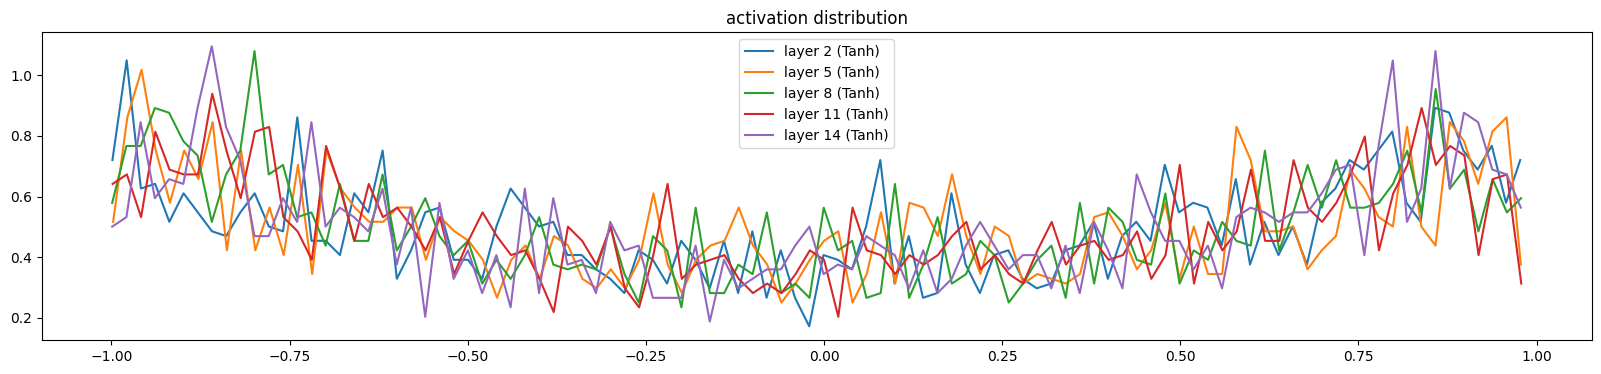

In [362]:
# visualize the activation
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out.detach()
        print('layer %d (%10s): mean %+.2f, std %.2f saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean() * 100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('activation distribution')

layer 2 (      Tanh): mean -0.000000, std 4.360862e-03
layer 5 (      Tanh): mean +0.000000, std 3.804866e-03
layer 8 (      Tanh): mean +0.000000, std 3.511071e-03
layer 11 (      Tanh): mean +0.000000, std 3.270142e-03
layer 14 (      Tanh): mean -0.000000, std 3.144625e-03


Text(0.5, 1.0, 'gradient distribution')

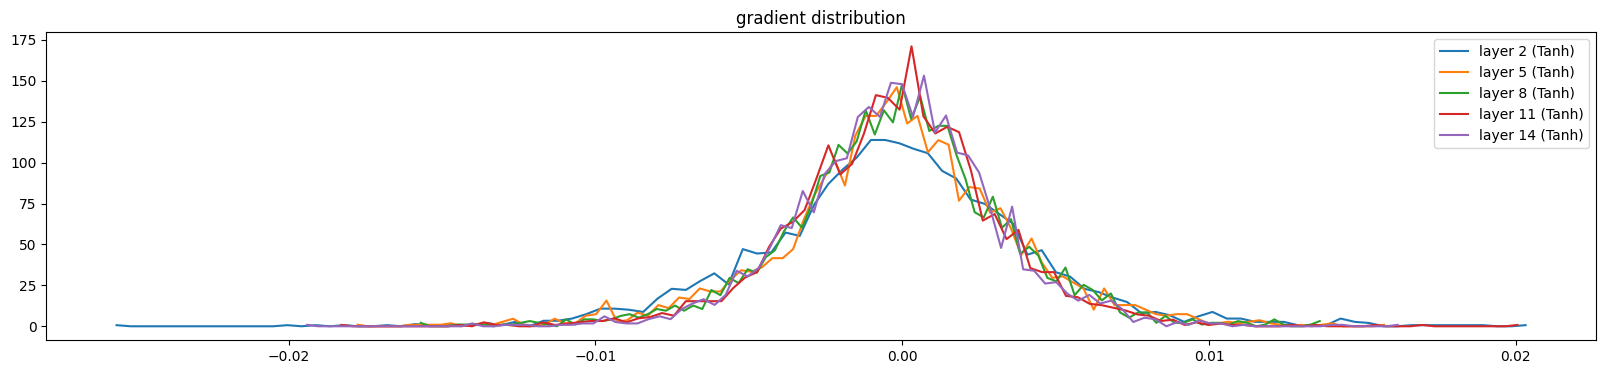

In [363]:
# visualize the gradient
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('gradient distribution')

weight   (27, 10) | mean +0.000000 | std 8.547097e-03 | grad:data ratio 8.283897e-03
weight  (30, 100) | mean -0.000005 | std 2.678890e-03 | grad:data ratio 2.606674e-03
weight (100, 100) | mean +0.000026 | std 1.376781e-03 | grad:data ratio 1.380235e-03
weight (100, 100) | mean +0.000004 | std 1.260896e-03 | grad:data ratio 1.251008e-03
weight (100, 100) | mean +0.000012 | std 1.097643e-03 | grad:data ratio 1.093700e-03
weight (100, 100) | mean -0.000011 | std 1.066149e-03 | grad:data ratio 1.061357e-03
weight  (100, 27) | mean -0.000035 | std 1.968947e-03 | grad:data ratio 1.988356e-03


Text(0.5, 1.0, 'weights gradient distribution')

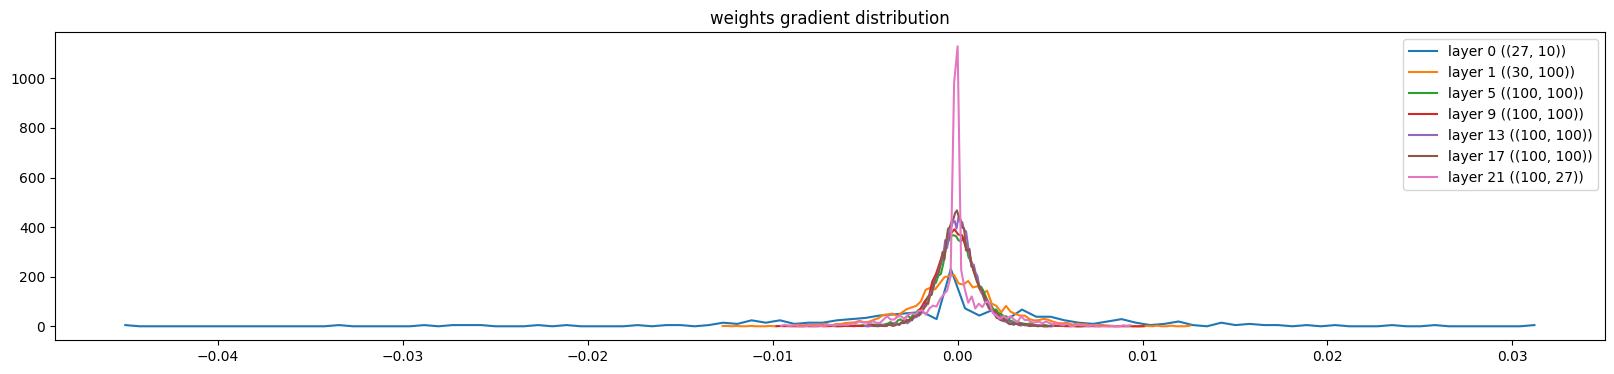

In [ ]:
# visualize the gradient
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:     # skip bias, gamma and beta, for simplicity reason
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std())) 
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({tuple(p.shape)})')
plt.legend(legends)
plt.title('weights gradient distribution')

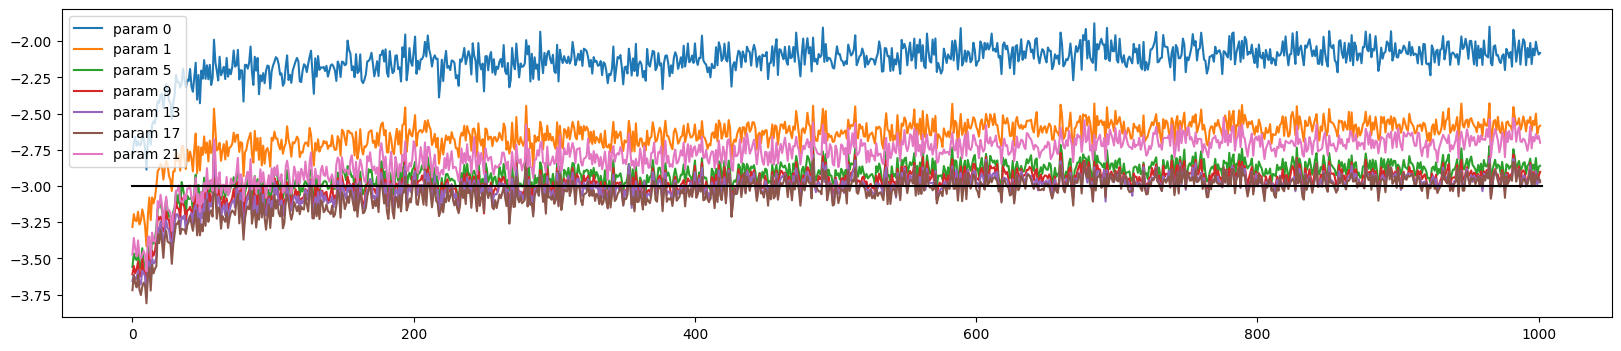

In [365]:
plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k')   # these ratios sould be ~1e-3, indicate on plot
plt.legend(legends)